# Spam or not? A text-message filter, and the parts that decide whether you can trust it

5,574 real text messages, 13% of them spam. Training a classifier on them takes a few lines. What makes a spam filter *good* is everything around those lines, and that is what this notebook is about:

- **Duplicates.** Spam is sent in bulk, so the same message appears many times. If a message sits in both the training and the test set, the test score is inflated. They are removed before anything is split.
- **The right error.** Blocking a real message from a friend is much worse than letting one spam through, so the filter is judged on **precision** (of the messages it blocks, how many really are spam) and on how much spam it still catches *at a very high precision*.
- **What it learned.** Which words make the filter suspicious, and whether those make sense.
- **How it fails.** The actual messages it gets wrong, and how easily a spammer can fool it by changing a few characters.
- **How much data it needs.** A learning curve.

**Data:** [SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) (Almeida and Hidalgo, 2011) from the UCI Machine Learning Repository (CC BY 4.0), downloaded into `SMS_DIR` on the first run (about 0.2 MB).

In [1]:
import os
import re
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

DATA_DIR = Path(os.environ.get("SMS_DIR", "sms_data"))
DATA_DIR.mkdir(exist_ok=True)
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.max_colwidth", 110)

## 1. Load the messages and deal with duplicates

In [2]:
zip_path = DATA_DIR / "sms_spam.zip"
if not zip_path.exists():
    urllib.request.urlretrieve("https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip", zip_path)
with zipfile.ZipFile(zip_path) as z:
    raw = pd.read_csv(z.open("SMSSpamCollection"), sep="\t", header=None, names=["label", "text"], quoting=3)
raw["spam"] = (raw.label == "spam").astype(int)

dup = raw.duplicated("text", keep=False)
print(f"{len(raw):,} messages, {raw.spam.mean():.1%} spam")
print(f"{raw.duplicated('text').sum()} are exact duplicates of an earlier message ({raw[raw.duplicated('text')].spam.mean():.0%} of those are spam)")
print(f"messages that appear with conflicting labels: {(raw.groupby('text').spam.nunique() > 1).sum()}")
df = raw.drop_duplicates("text").reset_index(drop=True)
print(f"after removing duplicates: {len(df):,} messages, {df.spam.mean():.1%} spam")

5,574 messages, 13.4% spam
403 are exact duplicates of an earlier message (23% of those are spam)
messages that appear with conflicting labels: 0
after removing duplicates: 5,171 messages, 12.6% spam


Duplicates are heavily skewed towards spam, which is exactly why they are dangerous: a model could score well just by recognising messages it has already seen. Everything below uses the de-duplicated messages.

## 2. What do spam and ham look like?

In [3]:
def traits(s):
    return pd.DataFrame({
        "characters": s.str.len(),
        "digits": s.str.count(r"\d"),
        "capitals": s.str.count(r"[A-Z]"),
        "has_number_of_6+_digits": s.str.contains(r"\d{6,}").astype(int),
        "has_currency": s.str.contains(r"[£$€]").astype(int),
        "has_link": s.str.contains(r"http|www\.", case=False).astype(int),
        "exclamation_marks": s.str.count("!"),
    })

t = traits(df.text).assign(spam=df.spam)
summary = t.groupby("spam").mean().T
summary.columns = ["ham", "spam"]
summary.round(2)

,ham,spam
characters,70.89,137.71
digits,0.30,15.49
capitals,3.97,15.27
has_number_of_6+_digits,0.00,0.56
has_currency,0.00,0.33
has_link,0.00,0.14
exclamation_marks,0.18,0.70


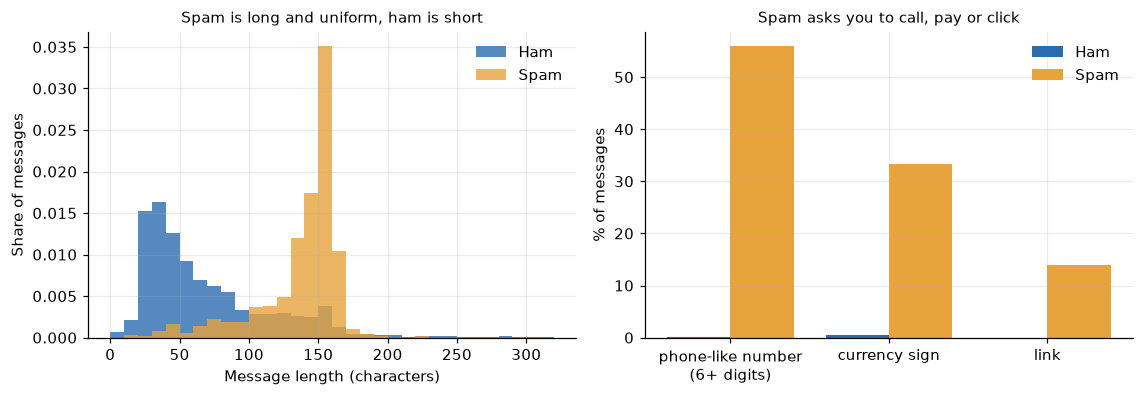

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
bins = np.arange(0, 330, 10)
axes[0].hist(t[t.spam == 0].characters, bins=bins, color=BLUE, alpha=0.8, label="Ham", density=True)
axes[0].hist(t[t.spam == 1].characters, bins=bins, color=AMBER, alpha=0.8, label="Spam", density=True)
axes[0].set_xlabel("Message length (characters)")
axes[0].set_ylabel("Share of messages")
axes[0].set_title("Spam is long and uniform, ham is short", fontsize=10)
axes[0].legend(frameon=False)
flags = ["has_number_of_6+_digits", "has_currency", "has_link"]
x = np.arange(len(flags))
axes[1].bar(x - 0.2, [t[t.spam == 0][f].mean() * 100 for f in flags], width=0.4, color=BLUE, label="Ham")
axes[1].bar(x + 0.2, [t[t.spam == 1][f].mean() * 100 for f in flags], width=0.4, color=AMBER, label="Spam")
axes[1].set_xticks(x, ["phone-like number\n(6+ digits)", "currency sign", "link"])
axes[1].set_ylabel("% of messages")
axes[1].set_title("Spam asks you to call, pay or click", fontsize=10)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## 3. Four ways to represent a message

A classifier needs numbers, so every message has to become a vector. Four increasingly rich versions are compared:

1. **Naive Bayes on word counts**: the classic spam filter.
2. **Logistic regression on TF-IDF words** (single words and pairs): TF-IDF down-weights words that appear everywhere.
3. **Words plus character n-grams** (2 to 5 characters inside words): catches `txt`, `txting`, `txts` as related, and survives some misspelling.
4. **Words, characters and a few hand-made signals**: length, digits and capitals share, currency sign, link, exclamation marks.

To keep the final test honest, 20% of the messages are locked away first. The models are compared by **5-fold cross-validation inside the other 80%**, using F1 (the balance of precision and recall for spam) and average precision.

In [5]:
train_text, test_text, y_train, y_test = train_test_split(df.text, df.spam, test_size=0.2, stratify=df.spam, random_state=0)
print(f"train {len(train_text):,} ({y_train.sum()} spam) | test {len(test_text):,} ({y_test.sum()} spam)")

def handmade(texts):
    s = pd.Series(list(texts))
    n = s.str.len().clip(lower=1)
    return np.c_[np.log1p(n), s.str.count(r"\d") / n, s.str.count(r"[A-Z]") / n, s.str.count("!"),
                 s.str.contains(r"http|www\.", case=False).astype(int), s.str.contains(r"[£$€]").astype(int)]

def words():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)

def chars():
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, sublinear_tf=True)

pipelines = {
    "Naive Bayes (word counts)": make_pipeline(CountVectorizer(ngram_range=(1, 2), min_df=2), MultinomialNB(alpha=0.3)),
    "Logistic regression, words": make_pipeline(words(), LogisticRegression(C=10, max_iter=2000)),
    "Logistic regression, words + characters": make_pipeline(FeatureUnion([("w", words()), ("c", chars())]),
                                                            LogisticRegression(C=10, max_iter=2000)),
    "Logistic regression, + hand-made signals": make_pipeline(
        FeatureUnion([("w", words()), ("c", chars()),
                      ("h", make_pipeline(FunctionTransformer(handmade), StandardScaler()))]),
        LogisticRegression(C=10, max_iter=2000)),
}
cv = StratifiedKFold(5, shuffle=True, random_state=0)
rows = {}
for name, pipe in pipelines.items():
    res = cross_validate(pipe, train_text, y_train, cv=cv, scoring={"f1": "f1", "average_precision": "average_precision",
                                                                    "precision": "precision", "recall": "recall"})
    rows[name] = {f"{m} (mean)": res[f"test_{m}"].mean() for m in ["f1", "precision", "recall", "average_precision"]}
    rows[name]["f1 (std)"] = res["test_f1"].std()
cv_results = pd.DataFrame(rows).T
cv_results.round(4)

train 4,136 (522 spam) | test 1,035 (131 spam)


,f1 (mean),precision (mean),recall (mean),average_precision (mean),f1 (std)
Naive Bayes (word counts),0.9371,0.9586,0.9177,0.9630,0.0167
"Logistic regression, words",0.9290,0.9809,0.8832,0.9763,0.0229
"Logistic regression, words + characters",0.9548,0.9980,0.9158,0.9858,0.0160
"Logistic regression, + hand-made signals",0.9524,0.9857,0.9214,0.9739,0.0116


The differences between the logistic models are small compared with the noise between folds (see the standard deviation), which is itself a finding: with 4,000 training messages, a cleverer representation buys little, and the hand-made signals do not beat plain words plus characters. The model with the best cross-validated average precision is chosen automatically, and its regularisation `C` is tuned:

In [6]:
BEST_NAME = cv_results["average_precision (mean)"].idxmax()
print("chosen by cross-validation:", BEST_NAME)
grid = GridSearchCV(pipelines[BEST_NAME], {"logisticregression__C": [1, 3, 10, 30, 100]}, scoring="average_precision", cv=cv)
grid.fit(train_text, y_train)
print("best C:", grid.best_params_["logisticregression__C"], "| cross-validated average precision:", round(grid.best_score_, 4))
model = grid.best_estimator_

chosen by cross-validation: Logistic regression, words + characters


best C: 10 | cross-validated average precision: 0.9858


## 4. The final test

The chosen model is scored once on the 20% of messages it has never seen. Two operating points are shown: the usual 0.5 cut-off, and a **high-precision cut-off**: the lowest threshold at which cross-validated precision on the training messages (not the test set) is still 99% or better, so that as much spam as possible is caught without blocking real messages. That is the kind of setting a mail provider would actually deploy.

In [7]:
from sklearn.model_selection import cross_val_predict

p_test = model.predict_proba(test_text)[:, 1]
p_cv = cross_val_predict(clone(model), train_text, y_train, cv=cv, method="predict_proba")[:, 1]

prec, rec, thr = precision_recall_curve(y_train, p_cv)
ok = np.where(prec[:-1] >= 0.99)[0]
CAUTIOUS = float(thr[ok[0]]) if len(ok) else 0.9
print(f"high-precision threshold (precision >= 99% in cross-validation): {CAUTIOUS:.3f}")

def report(threshold):
    pred = (p_test >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {"threshold": threshold, "precision": precision_score(y_test, pred), "recall": recall_score(y_test, pred),
            "F1": f1_score(y_test, pred), "ham blocked (false alarms)": fp, "spam missed": fn, "spam caught": tp}
final = pd.DataFrame({"usual cut-off": report(0.5), "high-precision cut-off": report(CAUTIOUS)}).T
print(f"ROC AUC {roc_auc_score(y_test, p_test):.4f} | average precision {average_precision_score(y_test, p_test):.4f}")
final.round(3)

high-precision threshold (precision >= 99% in cross-validation): 0.391
ROC AUC 0.9971 | average precision 0.9888


,threshold,precision,recall,F1,ham blocked (false alarms),spam missed,spam caught
usual cut-off,0.500,0.992,0.893,0.940,1.0,14.0,117.0
high-precision cut-off,0.391,0.992,0.901,0.944,1.0,13.0,118.0


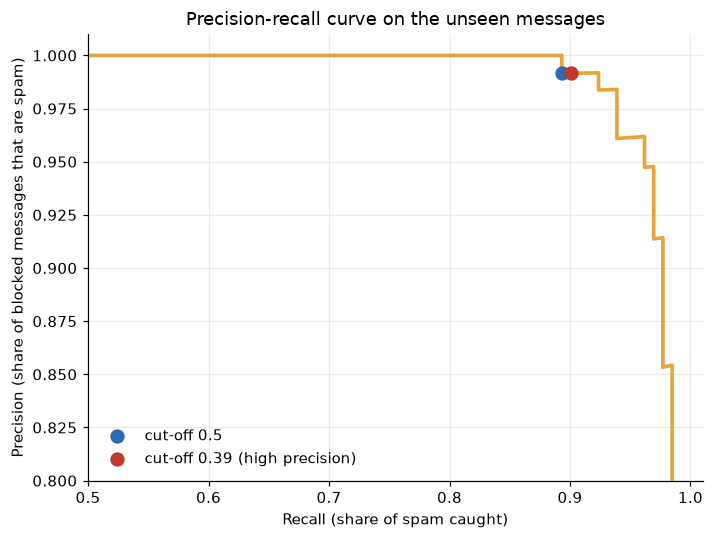

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 5))
prec_t, rec_t, thr_t = precision_recall_curve(y_test, p_test)
ax.plot(rec_t, prec_t, color=AMBER, lw=2.4)
for threshold, label, color in [(0.5, "0.5", BLUE), (CAUTIOUS, f"{CAUTIOUS:.2f} (high precision)", "#c0392b")]:
    r, p = recall_score(y_test, p_test >= threshold), precision_score(y_test, p_test >= threshold)
    ax.scatter([r], [p], s=70, color=color, zorder=3, label=f"cut-off {label}")
ax.set_xlabel("Recall (share of spam caught)")
ax.set_ylabel("Precision (share of blocked messages that are spam)")
ax.set_ylim(0.8, 1.01)
ax.set_xlim(0.5, 1.01)
ax.set_title("Precision-recall curve on the unseen messages")
ax.legend(frameon=False, loc="lower left")
fig.tight_layout()
plt.show()

## 5. What did it learn?

To see which words drive the decisions, a plain logistic regression on single words is fitted (it is almost as accurate and can be read directly). Its coefficients are the evidence each word adds towards spam (positive) or towards a normal message (negative). (`gt` and `lt` are not words: they are what is left of the web escape codes `&gt;` and `&lt;` that appear in many ordinary messages.)

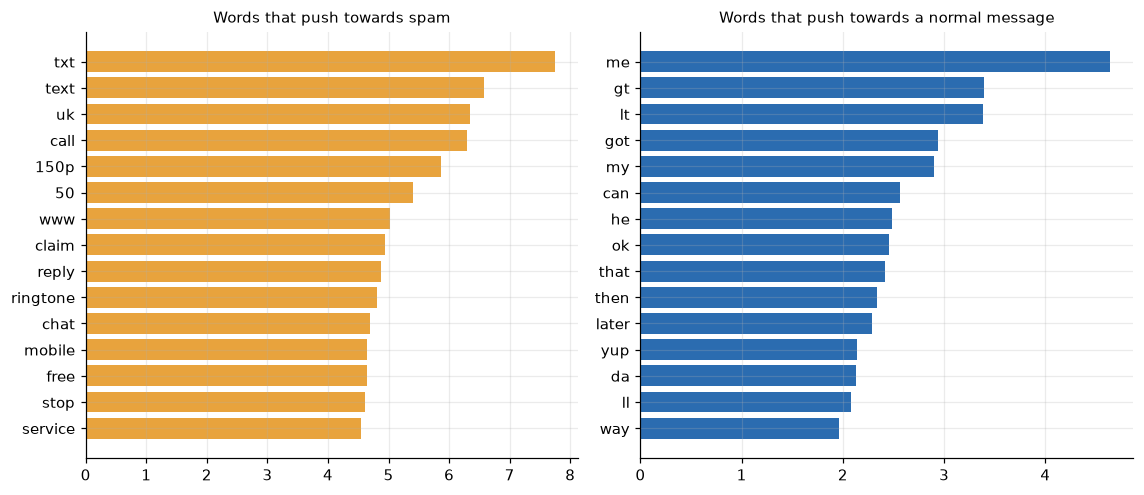

In [9]:
reader = make_pipeline(TfidfVectorizer(min_df=3, sublinear_tf=True), LogisticRegression(C=10, max_iter=2000)).fit(train_text, y_train)
vocab = np.array(reader[0].get_feature_names_out())
coef = reader[1].coef_[0]
top_spam = pd.Series(coef, index=vocab).nlargest(15)
top_ham = pd.Series(coef, index=vocab).nsmallest(15)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
axes[0].barh(top_spam.index[::-1], top_spam.values[::-1], color=AMBER)
axes[0].set_title("Words that push towards spam", fontsize=10)
axes[1].barh(top_ham.index[::-1], -top_ham.values[::-1], color=BLUE)
axes[1].set_title("Words that push towards a normal message", fontsize=10)
fig.tight_layout()
plt.show()

## 6. How does it fail?

Counting errors is not the same as understanding them. Here are the actual messages the model got wrong at the usual cut-off.

In [10]:
errors = pd.DataFrame({"text": test_text, "spam": y_test, "p_spam": p_test})
errors["verdict"] = np.where((errors.p_spam >= 0.5) & (errors.spam == 0), "ham blocked",
                      np.where((errors.p_spam < 0.5) & (errors.spam == 1), "spam missed", ""))
wrong = errors[errors.verdict != ""].copy()
wrong["text"] = wrong.text.str.replace(r"\s+", " ", regex=True).str.slice(0, 115)
wrong["p_spam"] = wrong.p_spam.round(2)
wrong.sort_values(["verdict", "p_spam"], ascending=[True, False])[["verdict", "p_spam", "text"]].reset_index(drop=True)

,verdict,p_spam,text
0,ham blocked,0.50,"We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us"
1,spam missed,0.45,Your weekly Cool-Mob tones are ready to download !This weeks new Tones include: 1) Crazy Frog-AXEL F>>> 2)...
2,spam missed,0.39,Bought one ringtone and now getting texts costing 3 pound offering more tones etc
3,spam missed,0.37,Block Breaker now comes in deluxe format with new features and great graphics from T-Mobile. Buy for just ...
4,spam missed,0.36,"Will u meet ur dream partner soon? Is ur career off 2 a flyng start? 2 find out free, txt HORO followed by..."
5,spam missed,0.34,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT G...
6,spam missed,0.27,thesmszone.com lets you send free anonymous and masked messages..im sending this message from there..do yo...
7,spam missed,0.21,Email AlertFrom: Jeri StewartSize: 2KBSubject: Low-cost prescripiton drvgsTo listen to email call 123
8,spam missed,0.17,You won't believe it but it's true. It's Incredible Txts! Reply G now to learn truly amazing things that w...
9,spam missed,0.15,"0A$NETWORKS allow companies to bill for SMS, so they are responsible for their ""suppliers"", just as a shop..."


### Can a spammer fool it?

A simple stress test: take the spam in the test set, change it in a way a spammer easily could, and see how much of it the filter still catches at its own high-precision cut-off. The changes are lower-casing everything, removing digits (which hides phone numbers and prices) and removing currency signs. Two models are compared: the one chosen above, and the version that also uses hand-made signals such as the digit share and the currency sign, which look like useful clues but turn out to be a weakness when a spammer removes them.

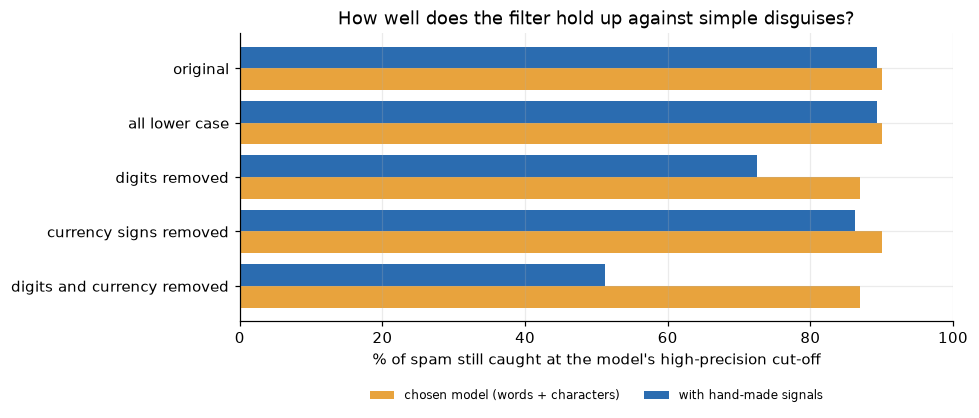

,chosen model (words + characters),with hand-made signals
original,0.901,0.893
all lower case,0.901,0.893
digits removed,0.870,0.725
currency signs removed,0.901,0.863
digits and currency removed,0.870,0.511


In [11]:
spam_test = test_text[y_test == 1]
variants = {
    "original": spam_test,
    "all lower case": spam_test.str.lower(),
    "digits removed": spam_test.str.replace(r"\d", "", regex=True),
    "currency signs removed": spam_test.str.replace(r"[£$€]", "", regex=True),
    "digits and currency removed": spam_test.str.replace(r"[\d£$€]", "", regex=True),
}

def high_precision_threshold(pipeline):
    p = cross_val_predict(clone(pipeline), train_text, y_train, cv=cv, method="predict_proba")[:, 1]
    pr, rc, th = precision_recall_curve(y_train, p)
    ok = np.where(pr[:-1] >= 0.99)[0]
    return float(th[ok[0]]) if len(ok) else 0.9

hand_model = clone(pipelines["Logistic regression, + hand-made signals"]).set_params(logisticregression__C=10).fit(train_text, y_train)
candidates = {"chosen model (words + characters)": (model, CAUTIOUS),
              "with hand-made signals": (hand_model, high_precision_threshold(hand_model))}
stress = pd.DataFrame({label: {name: (m.predict_proba(v)[:, 1] >= thr).mean() for name, v in variants.items()}
                       for label, (m, thr) in candidates.items()})
fig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(stress))
ax.barh(y_pos + 0.2, stress.iloc[:, 0] * 100, height=0.4, color=AMBER, label=stress.columns[0])
ax.barh(y_pos - 0.2, stress.iloc[:, 1] * 100, height=0.4, color=BLUE, label=stress.columns[1])
ax.set_yticks(y_pos, stress.index)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of spam still caught at the model's high-precision cut-off")
ax.set_title("How well does the filter hold up against simple disguises?")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=8)
fig.tight_layout()
plt.show()
stress.round(3)

## 7. How much labelled data does it need?

The same model is trained on random subsets of the training messages, each size repeated five times with different draws, and scored on the same unseen test messages.

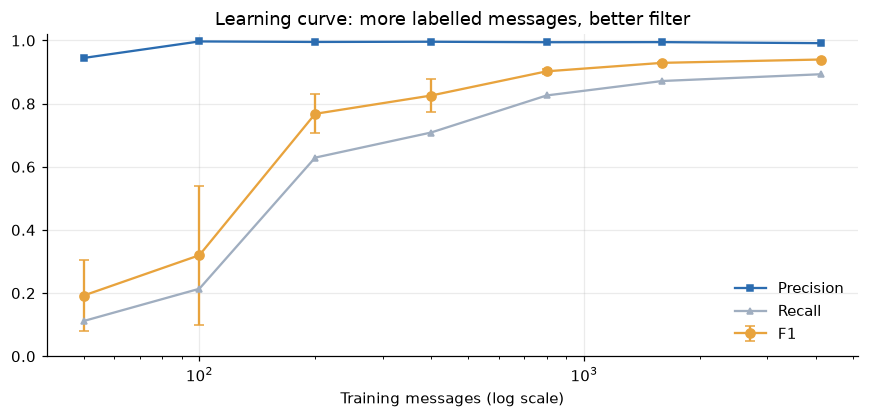

,F1,precision,recall,F1 std
training messages,,,,
50,0.192,0.945,0.111,0.112
100,0.320,0.997,0.214,0.221
200,0.768,0.995,0.629,0.062
400,0.826,0.996,0.708,0.052
800,0.902,0.994,0.826,0.008
1600,0.929,0.995,0.872,0.002
4136,0.940,0.992,0.893,0.000


In [12]:
sizes = [50, 100, 200, 400, 800, 1600, len(train_text)]
rng = np.random.default_rng(0)
curve = []
for n in sizes:
    scores = []
    for _ in range(5):
        if n == len(train_text):
            idx = np.arange(len(train_text))
        else:
            idx = rng.choice(len(train_text), size=n, replace=False)
        ys = y_train.iloc[idx]
        if ys.nunique() < 2:
            continue
        m = clone(model).fit(train_text.iloc[idx], ys)
        pred = m.predict(test_text)
        scores.append((f1_score(y_test, pred), precision_score(y_test, pred, zero_division=0), recall_score(y_test, pred)))
    curve.append((n, *np.mean(scores, axis=0), np.std([s[0] for s in scores])))
curve = pd.DataFrame(curve, columns=["training messages", "F1", "precision", "recall", "F1 std"]).set_index("training messages")

fig, ax = plt.subplots(figsize=(8, 3.9))
ax.errorbar(curve.index, curve.F1, yerr=curve["F1 std"], marker="o", color=AMBER, capsize=3, label="F1")
ax.plot(curve.index, curve.precision, marker="s", ms=4, color=BLUE, label="Precision")
ax.plot(curve.index, curve.recall, marker="^", ms=4, color=GREY, label="Recall")
ax.set_xscale("log")
ax.set_xlabel("Training messages (log scale)")
ax.set_ylim(0, 1.02)
ax.set_title("Learning curve: more labelled messages, better filter")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()
curve.round(3)

## What the results say

- **Duplicates were a real trap.** 403 of the 5,574 messages are exact copies of an earlier one, and 23% of those copies are spam, against 13.4% spam overall. Left in, a model could score well by recognising messages it had already seen. After removing them, 5,171 messages remain (12.6% spam), split 80% for training and cross-validation and 20% (1,035 messages, 131 of them spam) for a single final test.
- **A cleverer representation helps only a little.** In 5-fold cross-validation the Naive Bayes baseline reaches an F1 of 0.937 and logistic regression on words 0.929. Adding character n-grams brings F1 to 0.955, precision to 99.8% and average precision to 0.986, the best of the four. The hand-made signals (length, digit and capital share, currency, link, exclamation marks) add nothing (F1 0.952, average precision 0.974), and folds differ by about 0.01-0.02 in F1, so these gaps are small.
- **On unseen messages it blocks almost no real messages.** At the usual 0.5 cut-off the filter catches 117 of the 131 spam messages (recall 89.3%) with 99.2% precision, which means exactly one normal message blocked. A cut-off chosen only from the training data to keep cross-validated precision at 99% (0.39) catches 118 (90.1%) with the same single false alarm. The ROC AUC is 0.997 and the average precision 0.989.
- **The errors are instructive.** The one real message blocked is a job offer sent to a mail address, which reads like spam. The spam it misses is mostly disguised as ordinary or informative text: a complaint about getting ringtone texts, a horoscope service, an email-style alert, a game or ringtone announcement. These are the cases where even a person has to think.
- **The words it uses make sense.** The strongest signs of spam are `txt`, `text`, `uk`, `call`, `150p`, `www`, `claim`, `reply`, `ringtone` and `free`: messages that ask you to act or pay. The strongest signs of an ordinary message are everyday words like `me`, `got`, `my`, `ok` and `later`.
- **Clues that look useful can make the filter brittle.** When a spammer removes digits and currency signs, the chosen model still catches 87% of the spam, while the model that relies on digit share and currency signs falls from 89% to 51%. Lower-casing everything changes nothing for either. The model with the best cross-validated score was also the more robust one, which is not always the case.
- **Data needs are modest but not tiny.** With 50 labelled messages the filter is precise (94.5%) but finds only 11% of the spam. It reaches an F1 of 0.77 with 200 messages, 0.90 with 800 and 0.94 with all 4,136, and the curve is still rising, so more labelled messages would still help.

**Limits:** these are English-language messages collected in the 2000s, mostly from the UK and Singapore, so modern spam (links, phishing, other languages) looks different; the test set has only 131 spam messages, so a single error moves recall by about 0.8 points; labels are taken as correct although a few borderline messages are arguable; the stress test covers three simple disguises, not an adversary who adapts.

**Techniques covered:** duplicate removal before splitting, TF-IDF with word and character n-grams, Naive Bayes and logistic regression, cross-validation and grid search, choosing a threshold for a target precision from out-of-fold predictions, precision-recall curves, reading model coefficients, error analysis, a robustness stress test and a learning curve.
